# Байесовская классификация. Снедков Валентин, ЕТ-128
1. Выполните классификацию набора данных с помощью Байесовской классификации, варьируя соотношение мощностей обучающей и тестовой выборок от 60%:40% до 90%:10% с шагом 5%.
2. Вычислите показатели качества классификации: аккуратность (accuracy), точность (precision), полнота (recall), F-мера. Выполните визуализацию полученных результатов в виде диаграмм.
3. Подготовьте отчет о выполнении задания и загрузите отчет в формате PDF в систему. Отчет должен представлять собой связный и структурированный документ со следующими разделами:  
* формулировка задания;
* гиперссылка на каталог репозитория с исходными текстами, набором данных и др. сопутствующими материалами;
* рисунки с результатами визуализации;
* пояснения, раскрывающие смысл полученных результатов.

In [28]:
# Библиотеки
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import warnings
warnings.filterwarnings("ignore")

In [29]:
# Загрузка датасета Digits (Цифры)
digits = datasets.load_digits()
X = digits.data
y = digits.target

print(f"Размер датасета: {X.shape[0]} образцов, {X.shape[1]} признаков, {len(np.unique(y))} классов")

Размер датасета: 1797 образцов, 64 признаков, 10 классов


In [30]:
# Соотношения обучающей выборки от 60% до 90% с шагом 5%
train_ratios = list(range(60, 95, 5))
metrics = {'accuracy': [], 'precision': [], 'recall': [], 'f1': []}

In [31]:
for tr in train_ratios:
    ratio = tr / 100.0
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, train_size=ratio, random_state=42, stratify=y
    )

    model = GaussianNB()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    metrics['accuracy'].append(accuracy_score(y_test, y_pred))
    metrics['precision'].append(precision_score(y_test, y_pred, average='macro'))
    metrics['recall'].append(recall_score(y_test, y_pred, average='macro'))
    metrics['f1'].append(f1_score(y_test, y_pred, average='macro'))

    print(f"{tr}%: accuracy={metrics['accuracy'][-1]:.4f}, f1={metrics['f1'][-1]:.4f}, recall={metrics['recall'][-1]:.4f}, f1={metrics['f1'][-1]:.4f}")

60%: accuracy=0.8248, f1=0.8276, recall=0.8251, f1=0.8276
65%: accuracy=0.8315, f1=0.8356, recall=0.8313, f1=0.8356
70%: accuracy=0.8222, f1=0.8259, recall=0.8216, f1=0.8259
75%: accuracy=0.8289, f1=0.8305, recall=0.8284, f1=0.8305
80%: accuracy=0.8111, f1=0.8137, recall=0.8103, f1=0.8137
85%: accuracy=0.8259, f1=0.8267, recall=0.8264, f1=0.8267
90%: accuracy=0.8389, f1=0.8394, recall=0.8389, f1=0.8394


In [32]:
import pandas as pd

# Создаем DataFrame с результатами
results_table = pd.DataFrame({
    'Обучающая выборка (%)': train_ratios,
    'Тестовая выборка (%)': [100 - tr for tr in train_ratios],
    'Accuracy': [f"{acc:.4f}" for acc in metrics['accuracy']],
    'Precision': [f"{prec:.4f}" for prec in metrics['precision']],
    'Recall': [f"{rec:.4f}" for rec in metrics['recall']],
    'F1-score': [f"{f1:.4f}" for f1 in metrics['f1']]
})
results_table
print("\n" + "="*80)
print("ТАБЛИЦА РЕЗУЛЬТАТОВ КЛАССИФИКАЦИИ")
print("="*80)
print(results_table.to_string(index=False,justify = 'center'))
print("="*80)


ТАБЛИЦА РЕЗУЛЬТАТОВ КЛАССИФИКАЦИИ
 Обучающая выборка (%)  Тестовая выборка (%) Accuracy Precision Recall F1-score
          60                     40           0.8248    0.8610  0.8251  0.8276 
          65                     35           0.8315    0.8621  0.8313  0.8356 
          70                     30           0.8222    0.8526  0.8216  0.8259 
          75                     25           0.8289    0.8555  0.8284  0.8305 
          80                     20           0.8111    0.8463  0.8103  0.8137 
          85                     15           0.8259    0.8570  0.8264  0.8267 
          90                     10           0.8389    0.8554  0.8389  0.8394 


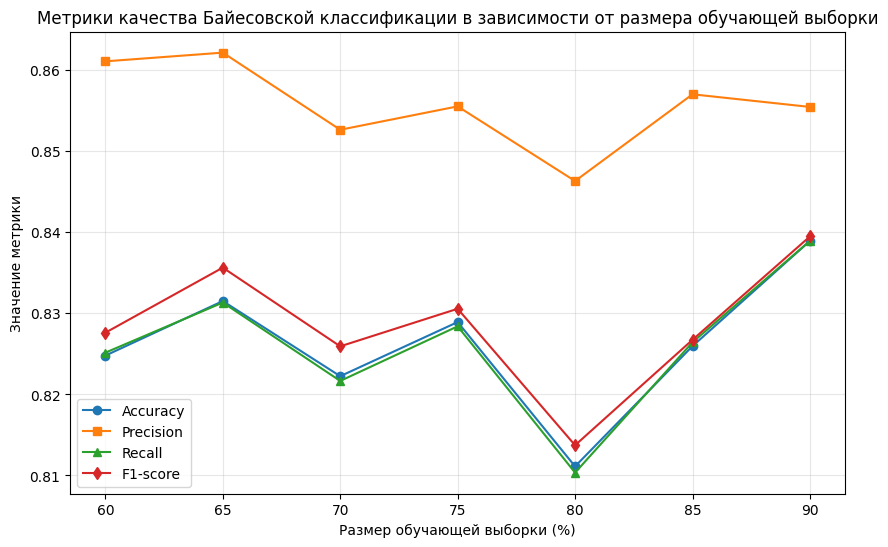

In [33]:
# Визуализация
plt.figure(figsize=(10, 6))
plt.plot(train_ratios, metrics['accuracy'], 'o-', label='Accuracy')
plt.plot(train_ratios, metrics['precision'], 's-', label='Precision')
plt.plot(train_ratios, metrics['recall'], '^-', label='Recall')
plt.plot(train_ratios, metrics['f1'], 'd-', label='F1-score')
plt.xlabel('Размер обучающей выборки (%)')
plt.ylabel('Значение метрики')
plt.title("Метрики качества Байесовской классификации в зависимости от размера обучающей выборки")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()
